# Python Equity Research & Portfolio Analytics

An interactive Python-based equity research and portfolio analytics project combining individual stock analysis with multi-asset portfolio optimisation.

The project evaluates historical performance, risk, technical indicators and benchmark-relative returns, and extends the analysis to portfolio diversification, risk-return optimisation, maximum Sharpe and minimum-volatility portfolio construction.

In [2]:
!pip install yfinance

## Import Libraries

In [3]:
import yfinance as yf

## 2. Download Historical Stock Data

In [4]:
company_ticker= "JPM"

In [5]:
company_ticker


'JPM'

## 2. Download Historical Stock Data

In [6]:
stock_data = yf.download(
    company_ticker,
    start="2021-01-01",
    end="2026-01-01",
    auto_adjust=True
)

[*********************100%***********************]  1 of 1 completed


## 3. Explore the Dataset

In [7]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,JPM,JPM,JPM,JPM,JPM
Date,,,,,
2021-01-04,109.000542,110.723834,108.056623,110.412082,16819900
2021-01-05,109.593636,110.160576,107.953870,109.017971,13731200
2021-01-06,114.739685,115.803787,111.538657,113.283090,24909100
2021-01-07,118.507652,120.531194,117.679052,118.350660,21940400
2021-01-08,118.638489,118.926321,116.981275,118.594875,12035100


## 3. Explore the Dataset

In [8]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1255 entries, 2021-01-04 to 2025-12-31
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, JPM)   1255 non-null   float64
 1   (High, JPM)    1255 non-null   float64
 2   (Low, JPM)     1255 non-null   float64
 3   (Open, JPM)    1255 non-null   float64
 4   (Volume, JPM)  1255 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.8 KB


## 3. Explore the Dataset

In [9]:
stock_data.shape

(1255, 5)

## 3. Explore the Dataset

In [10]:
stock_data.columns

MultiIndex([( 'Close', 'JPM'),
            (  'High', 'JPM'),
            (   'Low', 'JPM'),
            (  'Open', 'JPM'),
            ('Volume', 'JPM')],
           names=['Price', 'Ticker'])

## 4. Calculate Daily Returns

In [11]:
stock_data["Daily Return"]=stock_data["Close"][company_ticker].pct_change()

In [12]:
stock_data.head()

Price,Close,High,Low,Open,Volume,Daily Return
Ticker,JPM,JPM,JPM,JPM,JPM,
Date,,,,,,
2021-01-04,109.000542,110.723834,108.056623,110.412082,16819900,NaN
2021-01-05,109.593636,110.160576,107.953870,109.017971,13731200,0.005441
2021-01-06,114.739685,115.803787,111.538657,113.283090,24909100,0.046956
2021-01-07,118.507652,120.531194,117.679052,118.350660,21940400,0.032839
2021-01-08,118.638489,118.926321,116.981275,118.594875,12035100,0.001104


In [13]:
import matplotlib.pyplot as plt


## 5. Visualise the Stock Price

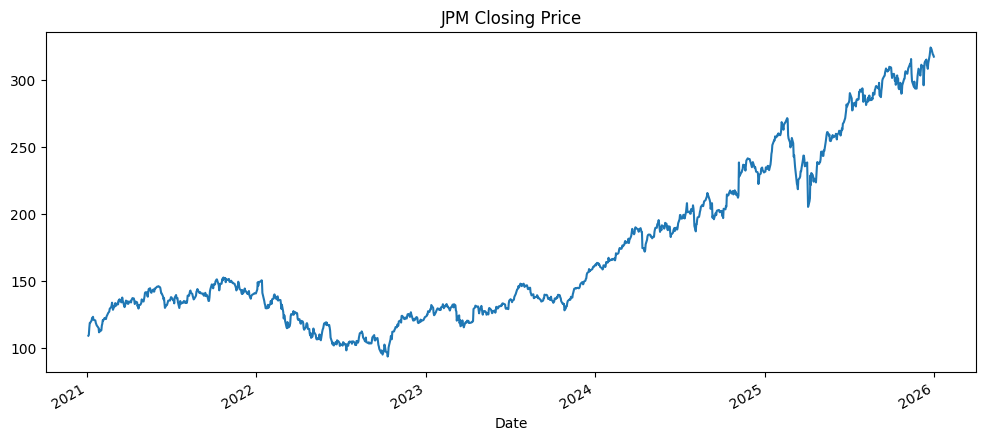

In [14]:
stock_data["Close"][company_ticker].plot(figsize=(12,5))
plt.title(f"{company_ticker} Closing Price")
plt.show()

In [15]:
stock_data["MA50"] = stock_data["Close"][company_ticker].rolling(50).mean()

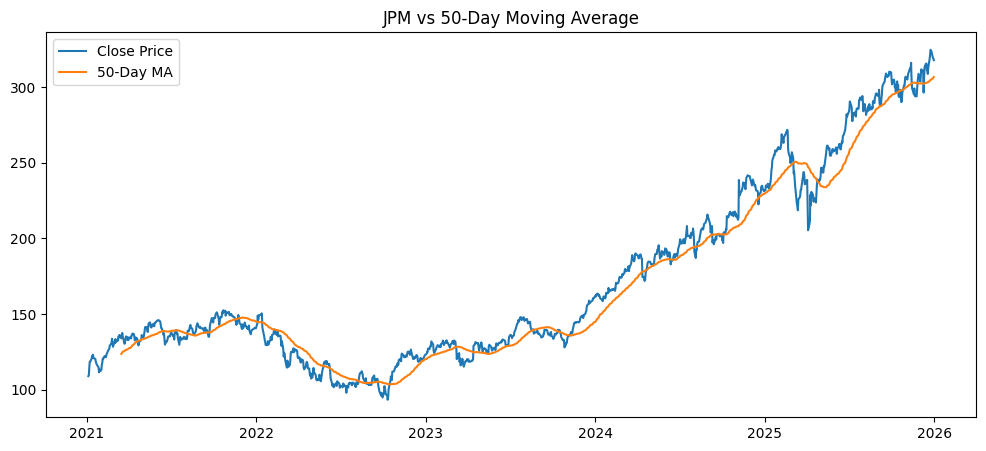

In [16]:
plt.figure(figsize=(12,5))
plt.plot(stock_data["Close"][company_ticker], label="Close Price")
plt.plot(stock_data["MA50"], label="50-Day MA")
plt.legend()
plt.title(f"{company_ticker} vs 50-Day Moving Average")
plt.show()

In [17]:
stock_data["MA200"] = stock_data["Close"][company_ticker].rolling(200).mean()

## 6. Moving Average Analysis

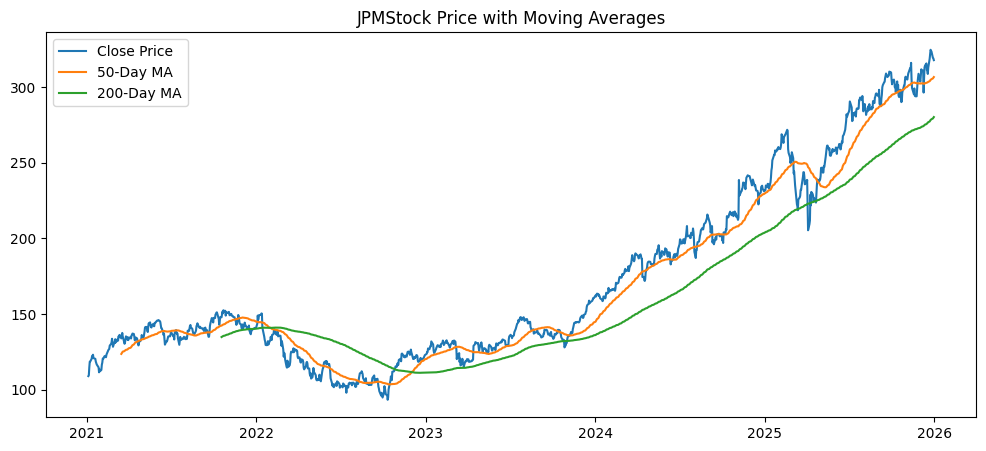

In [18]:
plt.figure(figsize=(12,5))

plt.plot(stock_data["Close"][company_ticker], label="Close Price")
plt.plot(stock_data["MA50"], label="50-Day MA")
plt.plot(stock_data["MA200"], label="200-Day MA")

plt.title(f"{company_ticker}Stock Price with Moving Averages")
plt.legend()

plt.show()

In [19]:
stock_data["Volatility"] = stock_data["Daily Return"].rolling(30).std()

## 7. Volatility Analysis

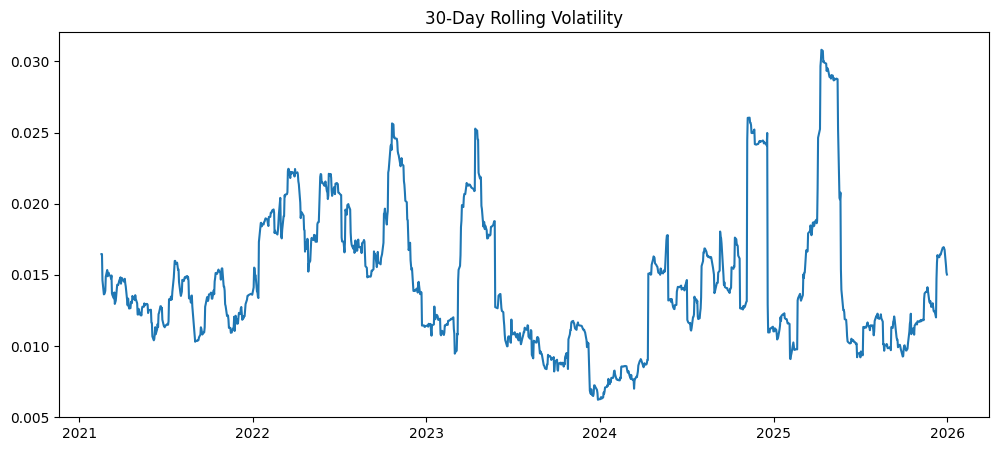

In [20]:
plt.figure(figsize=(12,5))

plt.plot(stock_data["Volatility"])

plt.title("30-Day Rolling Volatility")
plt.show()

## 8. Investment Performance

In [21]:
stock_data["Cumulative Return"] = (1 + stock_data["Daily Return"]).cumprod()

## 8. Investment Performance

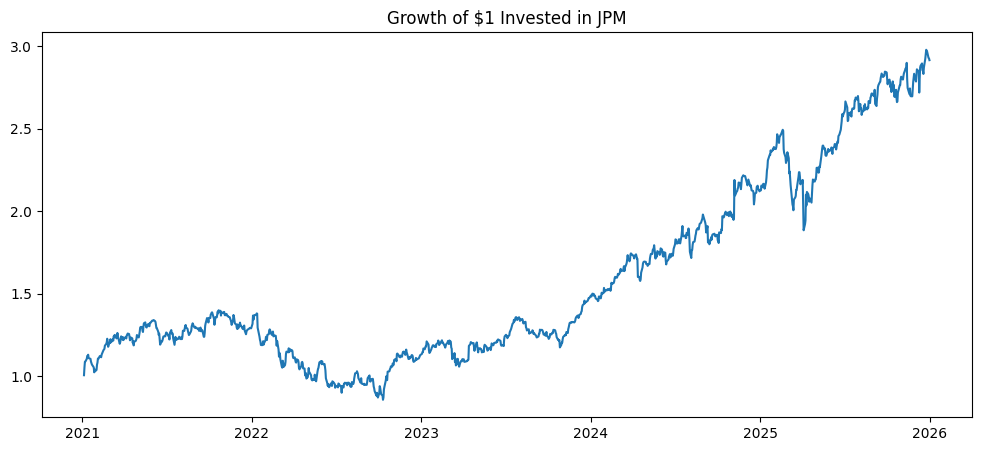

In [22]:
plt.figure(figsize=(12,5))

plt.plot(stock_data["Cumulative Return"])

plt.title(f"Growth of $1 Invested in {company_ticker}")

plt.show()

## 9. Trading Signal Strategy

In [23]:
stock_data["Signal"] = 0

In [24]:
stock_data.loc[stock_data["MA50"] > stock_data["MA200"], "Signal"] = 1

## 9. Trading Signal Strategy

In [25]:
stock_data["Position"] = stock_data["Signal"].diff()

## 9. Trading Signal Strategy

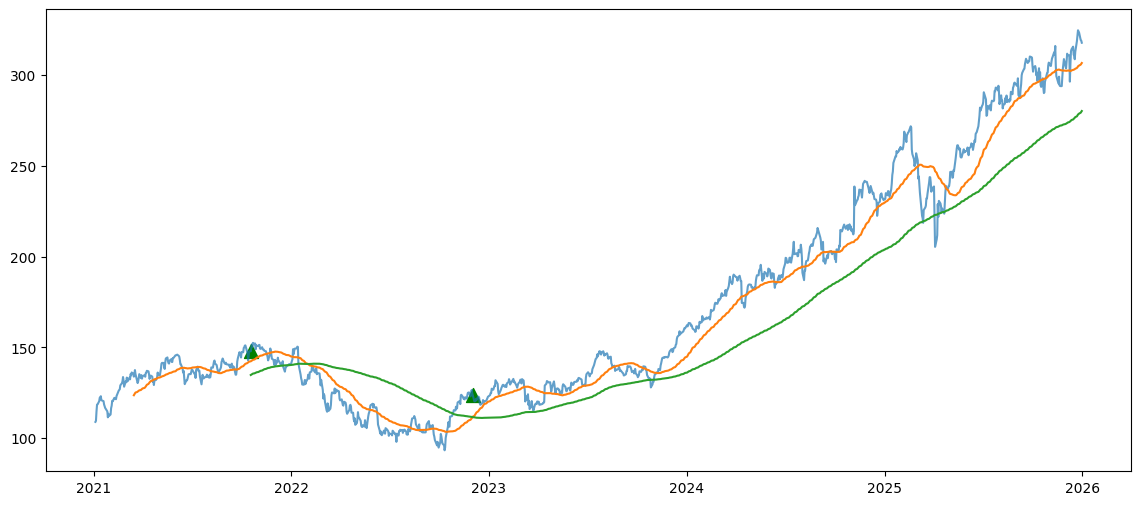

In [26]:
plt.figure(figsize=(14,6))

plt.plot(stock_data["Close"][company_ticker], label="Close Price", alpha=0.7)
plt.plot(stock_data["MA50"], label="50-Day MA")
plt.plot(stock_data["MA200"], label="200-Day MA")
plt.scatter(
    stock_data.index[stock_data["Position"] == 1],
    stock_data["Close"][company_ticker][stock_data["Position"] == 1],
    marker="^",
    color="green",
    s=100,
    label="Buy"
)

## 9. Trading Signal Strategy

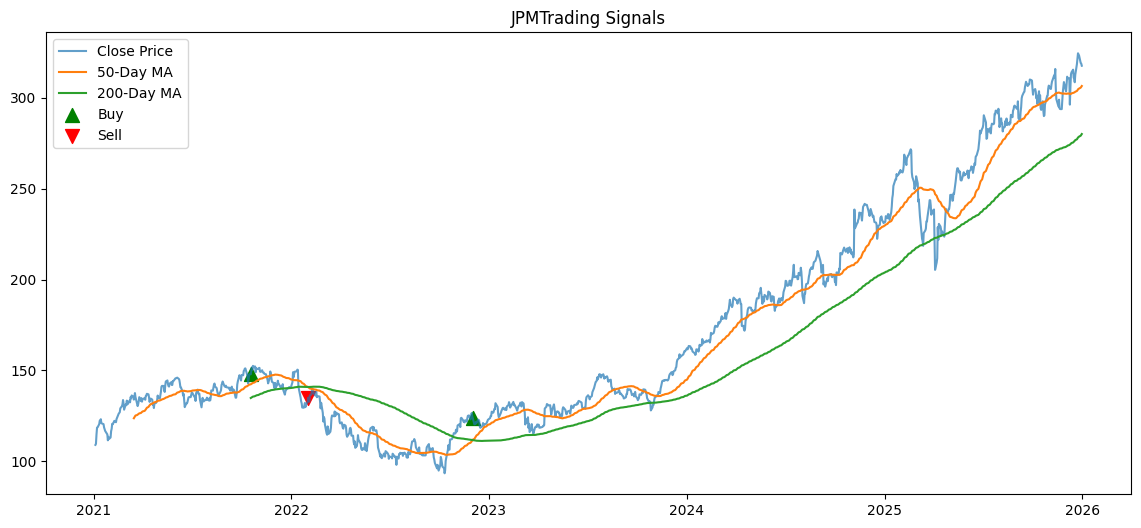

In [27]:
plt.figure(figsize=(14,6))

# Stock Price
plt.plot(stock_data["Close"][company_ticker], label="Close Price", alpha=0.7)

# Moving Averages
plt.plot(stock_data["MA50"], label="50-Day MA")
plt.plot(stock_data["MA200"], label="200-Day MA")

# Buy Signals
plt.scatter(
    stock_data.index[stock_data["Position"] == 1],
    stock_data["Close"][company_ticker][stock_data["Position"] == 1],
    marker="^",
    color="green",
    s=100,
    label="Buy"
)

# Sell Signals
plt.scatter(
    stock_data.index[stock_data["Position"] == -1],
    stock_data["Close"][company_ticker][stock_data["Position"] == -1],
    marker="v",
    color="red",
    s=100,
    label="Sell"
)

plt.title(f"{company_ticker}Trading Signals")
plt.legend()
plt.show()

In [28]:
 annual_return = stock_data["Daily Return"].mean() * 252

annual_volatility = stock_data["Daily Return"].std() * (252 ** 0.5)

sharpe_ratio = annual_return / annual_volatility

## 10. Performance Metrics

In [29]:
print("Annual Return:", annual_return)
print("Annual Volatility:", annual_volatility)
print("Sharpe Ratio:", sharpe_ratio)

Annual Return: 0.244469922994114
Annual Volatility: 0.2427465508173731
Sharpe Ratio: 1.0070994713248778


In [30]:
latest_price = stock_data["Close"][company_ticker].iloc[-1]

In [31]:
if stock_data["MA50"].iloc[-1] > stock_data["MA200"].iloc[-1]:
    trend = "Bullish"
else:
    trend = "Bearish"

In [32]:
print("----- JPM Summary -----")
print("Latest Price: $", round(latest_price, 2))
print("Annual Return:", round(annual_return * 100, 2), "%")
print("Annual Volatility:", round(annual_volatility * 100, 2), "%")
print("Sharpe Ratio:", round(sharpe_ratio, 2))
print("Current Trend:", trend)

----- JPM Summary -----
Latest Price: $ 317.71
Annual Return: 24.45 %
Annual Volatility: 24.27 %
Sharpe Ratio: 1.01
Current Trend: Bullish


## 11. Benchmark Comparison with the S&P 500

In [33]:
sp500 = yf.download("^GSPC", start="2021-01-01", end="2025-12-31")

/tmp/ipykernel_1483/2984967778.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start="2021-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed


In [34]:
sp500["Daily Return"] = sp500["Close"].pct_change()

In [35]:
sp500["Cumulative Return"] = (1 + sp500["Daily Return"]).cumprod()

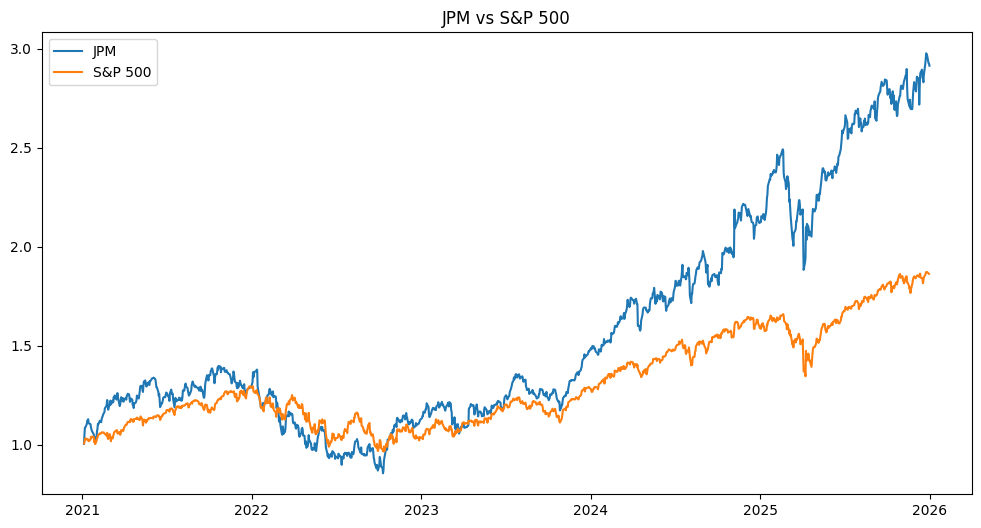

In [36]:
plt.figure(figsize=(12,6))

plt.plot(stock_data["Cumulative Return"], label="JPM")
plt.plot(sp500["Cumulative Return"], label="S&P 500")

plt.title(f"{company_ticker} vs S&P 500")
plt.legend()

plt.show()

In [37]:
import pandas as pd

## 12. Summary Dashboard

In [38]:
summary = {
    "Metric": [
        "Latest Price",
        "Annual Return",
        "Annual Volatility",
        "Sharpe Ratio",
        "Current Trend"
    ],
    "Value": [
        round(stock_data["Close"][company_ticker].iloc[-1], 2),
        f"{annual_return:.2%}",
        f"{annual_volatility:.2%}",
        round(sharpe_ratio, 2),
        "Bullish" if stock_data["Position"].iloc[-1] == 1 else "Bearish"
    ]
}

summary_df = pd.DataFrame(summary)

summary_df

,Metric,Value
0,Latest Price,317.71
1,Annual Return,24.45%
2,Annual Volatility,24.27%
3,Sharpe Ratio,1.01
4,Current Trend,Bearish


# Conclusion

This project analysed the historical performance of a publicly traded company using Python.

Key findings:

- Calculated historical returns and volatility.
- Analysed moving-average trends.
- Generated buy and sell signals.
- Compared performance against the S&P 500.
- Calculated risk-adjusted returns using the Sharpe Ratio.


# Investment Recommendation

## Recommendation: HOLD

### Reasons

- The company generated strong long-term returns.
- Performance was compared against the S&P 500.
- The Sharpe Ratio indicates reasonable risk-adjusted returns.
- Technical indicators (50-day and 200-day moving averages) were analysed to identify buy and sell signals.
- This project is intended for educational purposes and should not be considered financial advice.

# Analyst Commentary

This project analysed the historical stock performance of a publicly traded company using Python and Yahoo Finance.

## Key Findings

- Calculated daily returns and cumulative returns.
- Measured annual return, annual volatility and Sharpe Ratio.
- Analysed 50-day and 200-day moving averages to identify trend changes.
- Compared performance against the S&P 500 benchmark.
- Built a reusable dashboard by changing only the `company_ticker` variable.

# Portfolio Analytics & Optimisation

In [39]:
portfolio_tickers = ["JPM", "MSFT", "AAPL", "NVDA", "GOOGL"]

portfolio_data = yf.download(
    portfolio_tickers,
    start="2021-01-01",
    end="2026-01-01"
)["Close"]

portfolio_data.head()

/tmp/ipykernel_1483/271909780.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  portfolio_data = yf.download(
[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,GOOGL,JPM,MSFT,NVDA
Date,,,,,
2021-01-04,125.740845,85.547935,109.000542,207.956116,13.060795
2021-01-05,127.295509,86.237816,109.593636,208.156754,13.350874
2021-01-06,123.010521,85.386841,114.739685,202.759369,12.563801
2021-01-07,127.208046,87.937233,118.507652,208.529312,13.290370
2021-01-08,128.306015,89.101418,118.638489,209.799835,13.223387


In [40]:
portfolio_returns = portfolio_data.pct_change().dropna()

portfolio_returns.head()

Ticker,AAPL,GOOGL,JPM,MSFT,NVDA
Date,,,,,
2021-01-05,0.012364,0.008064,0.005441,0.000965,0.022210
2021-01-06,-0.033662,-0.009868,0.046956,-0.025929,-0.058953
2021-01-07,0.034123,0.029869,0.032839,0.028457,0.057830
2021-01-08,0.008631,0.013239,0.001104,0.006093,-0.005040
2021-01-11,-0.023249,-0.023106,0.014924,-0.009699,0.025967


In [45]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [46]:
annual_returns = portfolio_returns.mean() * 252
annual_volatility = portfolio_returns.std() * np.sqrt(252)

portfolio_summary = pd.DataFrame({
    "Annual Return": annual_returns,
    "Annual Volatility": annual_volatility
})

portfolio_summary

,Annual Return,Annual Volatility
Ticker,,
AAPL,0.193226,0.278626
GOOGL,0.308933,0.311455
JPM,0.244470,0.242747
MSFT,0.201725,0.257143
NVDA,0.669495,0.522247


In [47]:
correlation_matrix = portfolio_returns.corr()
correlation_matrix

Ticker,AAPL,GOOGL,JPM,MSFT,NVDA
Ticker,,,,,
AAPL,1.000000,0.578543,0.345422,0.633958,0.519852
GOOGL,0.578543,1.000000,0.321411,0.644270,0.527608
JPM,0.345422,0.321411,1.000000,0.311269,0.315992
MSFT,0.633958,0.644270,0.311269,1.000000,0.630455
NVDA,0.519852,0.527608,0.315992,0.630455,1.000000


In [48]:
num_portfolios = 10000

results = []

for i in range(num_portfolios):
    weights = np.random.random(len(portfolio_tickers))
    weights = weights / np.sum(weights)

    portfolio_return = np.sum(weights * annual_returns)

    portfolio_volatility = np.sqrt(
        np.dot(weights.T, np.dot(portfolio_returns.cov() * 252, weights))
    )

    sharpe_ratio = portfolio_return / portfolio_volatility

    results.append([
        portfolio_return,
        portfolio_volatility,
        sharpe_ratio,
        *weights
    ])

In [49]:
columns = [
    "Return",
    "Volatility",
    "Sharpe Ratio"
] + portfolio_tickers

portfolio_results = pd.DataFrame(
    results,
    columns=columns
)

portfolio_results.head()

,Return,Volatility,Sharpe Ratio,JPM,MSFT,AAPL,NVDA,GOOGL
0,0.333218,0.254888,1.307315,0.151020,0.058331,0.261759,0.282328,0.246562
1,0.268395,0.235337,1.140469,0.261657,0.341514,0.138439,0.202031,0.056358
2,0.315397,0.244580,1.289545,0.299716,0.152581,0.256854,0.100838,0.190012
3,0.340509,0.257784,1.320909,0.279399,0.051322,0.295102,0.111137,0.263040
4,0.272867,0.232227,1.175002,0.429204,0.173527,0.238287,0.060640,0.098342


In [50]:
max_sharpe_portfolio = portfolio_results.loc[
    portfolio_results["Sharpe Ratio"].idxmax()
]

min_volatility_portfolio = portfolio_results.loc[
    portfolio_results["Volatility"].idxmin()
]

print("MAXIMUM SHARPE RATIO PORTFOLIO")
print(max_sharpe_portfolio)

print("\nMINIMUM VOLATILITY PORTFOLIO")
print(min_volatility_portfolio)

MAXIMUM SHARPE RATIO PORTFOLIO
Return          0.420344
Volatility      0.290778
Sharpe Ratio    1.445586
JPM             0.015808
MSFT            0.137970
AAPL            0.450667
NVDA            0.000706
GOOGL           0.394849
Name: 4360, dtype: float64

MINIMUM VOLATILITY PORTFOLIO
Return          0.231637
Volatility      0.200372
Sharpe Ratio    1.156033
JPM             0.197360
MSFT            0.076127
AAPL            0.510546
NVDA            0.212537
GOOGL           0.003430
Name: 1895, dtype: float64


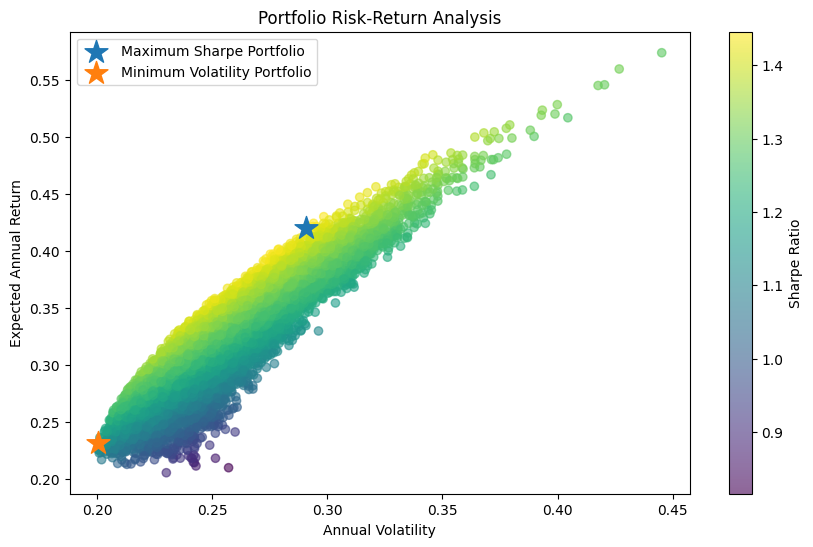

In [51]:
plt.figure(figsize=(10, 6))

plt.scatter(
    portfolio_results["Volatility"],
    portfolio_results["Return"],
    c=portfolio_results["Sharpe Ratio"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(label="Sharpe Ratio")

plt.scatter(
    max_sharpe_portfolio["Volatility"],
    max_sharpe_portfolio["Return"],
    marker="*",
    s=300,
    label="Maximum Sharpe Portfolio"
)

plt.scatter(
    min_volatility_portfolio["Volatility"],
    min_volatility_portfolio["Return"],
    marker="*",
    s=300,
    label="Minimum Volatility Portfolio"
)

plt.xlabel("Annual Volatility")
plt.ylabel("Expected Annual Return")
plt.title("Portfolio Risk-Return Analysis")
plt.legend()
plt.show()

In [52]:
allocation_table = pd.DataFrame({
    "Maximum Sharpe Portfolio": max_sharpe_portfolio[portfolio_tickers] * 100,
    "Minimum Volatility Portfolio": min_volatility_portfolio[portfolio_tickers] * 100
})

allocation_table = allocation_table.round(2)

allocation_table

,Maximum Sharpe Portfolio,Minimum Volatility Portfolio
JPM,1.58,19.74
MSFT,13.80,7.61
AAPL,45.07,51.05
NVDA,0.07,21.25
GOOGL,39.48,0.34


In [53]:
portfolio_comparison = pd.DataFrame({
    "Maximum Sharpe Portfolio": [
        max_sharpe_portfolio["Return"] * 100,
        max_sharpe_portfolio["Volatility"] * 100,
        max_sharpe_portfolio["Sharpe Ratio"]
    ],
    "Minimum Volatility Portfolio": [
        min_volatility_portfolio["Return"] * 100,
        min_volatility_portfolio["Volatility"] * 100,
        min_volatility_portfolio["Sharpe Ratio"]
    ]
}, index=[
    "Expected Annual Return (%)",
    "Annual Volatility (%)",
    "Sharpe Ratio"
])

portfolio_comparison.round(2)

,Maximum Sharpe Portfolio,Minimum Volatility Portfolio
Expected Annual Return (%),42.03,23.16
Annual Volatility (%),29.08,20.04
Sharpe Ratio,1.45,1.16


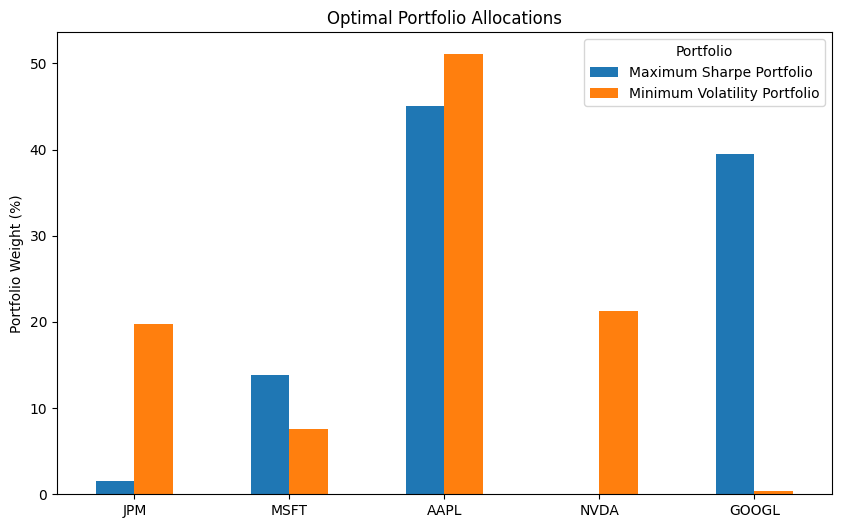

In [54]:
allocation_table.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("Portfolio Weight (%)")
plt.title("Optimal Portfolio Allocations")
plt.xticks(rotation=0)
plt.legend(title="Portfolio")
plt.show()

## Portfolio Analyst Commentary

### Methodology
- Analysed a five-stock portfolio consisting of JPM, MSFT, AAPL, NVDA and GOOGL using historical market data from 2021–2025.
- Calculated daily returns, annualised expected returns and annualised volatility.
- Evaluated correlations between securities to assess diversification.
- Simulated 10,000 randomly weighted portfolios and calculated the expected return, volatility and Sharpe ratio of each.
- Identified the maximum Sharpe ratio portfolio and minimum volatility portfolio from the simulated portfolios.

### Key Findings
- The maximum Sharpe portfolio provided the strongest historical risk-adjusted return among the simulated portfolios.
- The minimum volatility portfolio demonstrated how portfolio weights can be adjusted to prioritise lower overall risk.
- Differences in correlations between the securities created diversification benefits and affected overall portfolio volatility.
- Portfolio optimisation illustrates the trade-off between expected return and risk when constructing a multi-asset portfolio.

### Limitations
- Expected returns, volatility and correlations are estimated using historical data and do not predict future performance.
- The analysis uses a simplified Sharpe ratio assuming a 0% risk-free rate.
- Results depend on the selected securities, historical period and number of simulated portfolios.
- Transaction costs, taxes and other practical investment constraints are not included.

*This project is intended for educational purposes and does not constitute investment advice.*